# Parte 1: Captação e Avaliação da Qualidade dos Dados
Este notebook documenta a primeira etapa do trabalho da disciplina de Modelos Lineares Generalizados[cite: 1904, 1926]. 
O objetivo é realizar a auditoria da base de dados do PIB dos Municípios (IBGE), identificando anomalias antes da modelagem estatística[cite: 1924, 1928].

In [2]:
import sys
from pathlib import Path

# Adicionar o diretório raiz do projeto ao path para importar config
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from config import PIB_MUNICIPIOS_RAW, PIB_MUNICIPIOS_PROCESSED

# Configurações de exibição para facilitar a auditoria conforme Unidade 1 [cite: 1022]
%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 1. Captação de Dados
Conforme as instruções do trabalho, utilizamos a base "PIB MUNICIPIO" fornecida pela professora[cite: 1927]. 
Os dados estão integrados ao Sistema de Contas Nacionais (SCN) e em conformidade com o manual SNA 2008 e a classificação CNAE 2.0[cite: 1921].

In [3]:
# Carregando a base de dados usando o path configurado
try:
    df = pd.read_excel(PIB_MUNICIPIOS_RAW)
    print(f"Base carregada: {df.shape[0]} registros e {df.shape[1]} colunas.")
except Exception as e:
    print(f"Erro ao carregar: {e}. Verifique se o arquivo está na pasta data/raw/")

Base carregada: 77965 registros e 43 colunas.


## 2. Avaliação da Qualidade e Estatística Descritiva
Nesta etapa, realizamos a verificação da qualidade dos dados utilizando estatísticas descritivas[cite: 1928]. 
O foco é identificar **Missing Values** (dados faltantes) e **Outliers** (valores discrepantes) que possam comprometer o ajuste do modelo na Parte 2[cite: 1048, 1061].

In [4]:
# Verificação de Missing Values [cite: 1908, 1928]
print("--- Identificação de Missing Values ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

# Estatística Descritiva da Variável Alvo (Agropecuária) [cite: 1924]
col_alvo = 'Valor adicionado bruto da Agropecuária, \na preços correntes\n(R$ 1.000)'

print(f"\n--- Estatística Descritiva: {col_alvo} ---")
display(df[col_alvo].describe())

--- Identificação de Missing Values ---
Região Metropolitana                                                                                                                                    58419
Código Concentração Urbana                                                                                                                              68734
Nome Concentração Urbana                                                                                                                                68734
Tipo Concentração Urbana                                                                                                                                68734
Código Arranjo Populacional                                                                                                                             64590
Nome Arranjo Populacional                                                                                                                               64590
Valor adicio

count     66825.00
mean      53206.73
std      113620.80
min       -2298.91
25%        9510.44
50%       23760.52
75%       55289.03
max     5004238.72
Name: Valor adicionado bruto da Agropecuária, \na preços correntes\n(R$ 1.000), dtype: float64

### 2.1 Identificação Visual de Outliers
Utilizaremos um **Boxplot** para visualizar a dispersão. Como visto na revisão de Modelos Lineares, 
dados atípicos podem comprometer o resultado do ajuste da curva[cite: 1061, 1082].

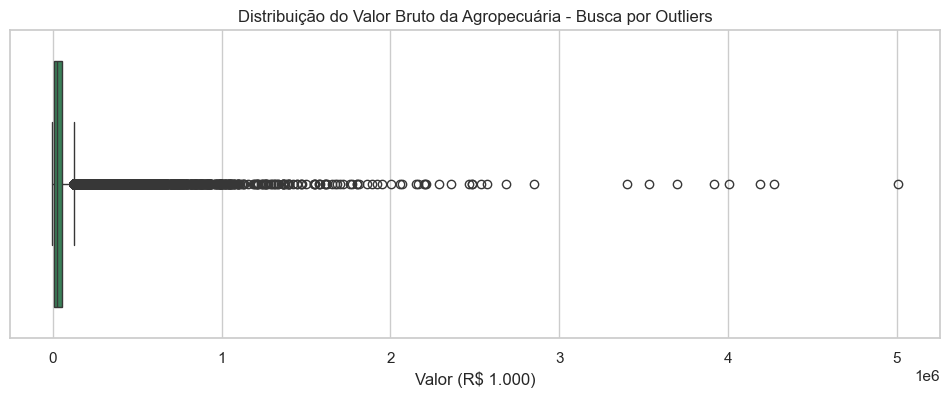

In [5]:
plt.figure(figsize=(12, 4))
sns.boxplot(x=df[col_alvo], color='seagreen')
plt.title('Distribuição do Valor Bruto da Agropecuária - Busca por Outliers')
plt.xlabel('Valor (R$ 1.000)')
plt.show()

## 3. Limpeza e Tratamento de Anomalias
Com base na auditoria, aplicamos os tratamentos necessários para garantir a integridade da análise[cite: 1909, 1919]:
1. Remoção de valores nulos na variável alvo para evitar viés na predição.
2. Remoção de duplicatas para garantir a consistência dos dados.
3. Exportação dos dados limpos para a pasta `processed` para uso na Parte 2 do trabalho[cite: 1944].

In [6]:
# 1. Tratamento de nulos na variável dependente [cite: 1928]
df_clean = df.dropna(subset=[col_alvo])

# 2. Remoção de duplicatas
df_clean = df_clean.drop_duplicates()

# 3. Exportação dos dados processados usando o path configurado
df_clean.to_csv(PIB_MUNICIPIOS_PROCESSED, index=False)

print(f"Processamento concluído. {len(df) - len(df_clean)} registros removidos.")
print(f"Arquivo salvo para a Parte 2 em: {PIB_MUNICIPIOS_PROCESSED}")

Processamento concluído. 11140 registros removidos.
Arquivo salvo para a Parte 2 em: c:\Projetos\trabalho-mlg-pib-municipios\data\processed\pib_municipios_limpo.csv
